# CSC349A - Fall 2025 - Assignment 1 - Instructor: George Tzanetakis


Some of the questions of the assignments are recycled from previous years but typically
with small changes in either the description or the numbers. Any submission that
contains numbers from previous years in any questions will be immediately graded
with zero.



# QUESTION 1

A Python function **Euler** for Euler’s method (as described in class) for solving the falling parachutist problem modeled by the differential equation:
$\frac{dv}{dt} = g - \frac{c}{m} v $ is given below.

As discussed in class, this numerical method is obtained by approximating $\frac{dv}{dt}$ at time $t_i$ by
$\frac{v(t_{i+1})-v(t_i)}{t_{i+1}-t_i}$, which results in the computed approximation:
$$
v(t_{t+1}) = v(t_i) + \left[ g-\frac{c}{m} v(t_i) \right] (t_{i+1}-t_i).
$$


In order to use the above function, you must specify values for the 7 local parameters in the function Euler:
> **m** is the mass of the falling object
> **c** is the drag coefficient.    
> **g** is the gravity constant    
> **t0** is the initial time, **v0** is the initial velocity    
> **tn** is the final time at which the velocity is to be computed    
> **n** is the number of time steps into which $[t_0 , t_n]$ is divided

Thus, in the function **Euler**, the step size $h = (t_n - t_0)/n$ is computed,
and Euler's method is used to compute an approximation to the solution $v(t)$ of the differential
equation at the $n$ points (values of time)
$$
	t_0 + h,\   t_0 + 2h,\   t_0 + 3h,\   t_0 + 4h,\   \ldots ,\  t_0 + nh \ =\  t_n.
$$


## Question 1a
Write a function **skyfall_euler** in Python that implements this numerical approach and returns an array with the first column containing the times and the second column containing the velocity values. Check that the function works for the values in the textbook example.
$m = 68.1$, $c = 12.5$ and initial
conditions $v(0) = 0$ on the time interval $[0, 12]$ using $6$ time steps and $g = 9.81$.

The resulting array should be named **result_1a**

In [1]:
import numpy as np

In [3]:
# compute the Euler-based numerical approximation
# to the falling parachutist problem
#
# return the result as a np.array with two columns
# the first one containing the times in seconds
# and the second the values of the approximation

def skyfall_euler(m,c,g,t0,v0,tn,n):
  h = (tn-t0)/n
  t = t0
  v = v0
  result = np.zeros((n+1,2))
  result[0] = [t,v]
  for i in range(1,n+1):
    v=v+(g-c/m*v)*h
    t=t+h
    result[i,:] = [t,v]
  return result


def output_values(result):
  print('value of t approximation v(t)\n')
  for r in result:
    t,v = r
    print(f"{t:8.3f} {v:19.4f}")




In [6]:
# Your code goes here
result_1a = skyfall_euler(68.1, 12.5, 9.81, 0, 0 , 12, 6)
output_values(result_1a)

value of t approximation v(t)

   0.000              0.0000
   2.000             19.6200
   4.000             32.0374
   6.000             39.8962
   8.000             44.8700
  10.000             48.0179
  12.000             50.0102


## Question 1b

Use the provided **skyfall_euler** function  to solve the diﬀerential equation using $m = 62.8$, $c = 12.5$ and initial
conditions $v(0) = 0$ on the time interval $[0, 12]$ using $15$ time steps and $g = 9.81$. The resulting array should be named **result_1b**.

In [7]:
# Your code goes here

result_1b = skyfall_euler(62.8, 12.5, 9.81, 0, 0 , 12, 15)
output_values(result_1b)

value of t approximation v(t)

   0.000              0.0000
   0.800              7.8480
   1.600             14.4463
   2.400             19.9939
   3.200             24.6582
   4.000             28.5797
   4.800             31.8768
   5.600             34.6489
   6.400             36.9796
   7.200             38.9391
   8.000             40.5866
   8.800             41.9718
   9.600             43.1364
  10.400             44.1155
  11.200             44.9388
  12.000             45.6309


In [17]:
## Question 1c

Use the provided **skyfall_euler** to solve the diﬀerential equation using $m = 62.8$, $c = 12.5$ and initial
conditions $v(0) = 0$ on the time interval $[0, 12]$ using $15$ time steps. Use a gravitational constant of 3.71 (as would be the case if the parachutist was falling on Mars). The resulting array should be named  **result_1c**.

SyntaxError: invalid syntax (1788159319.py, line 3)

In [18]:
# Your code goes here



value of t approximation v(t)

   0.000              0.0000
   0.800              2.9680
   1.600              5.4634
   2.400              7.5614
   3.200              9.3254
   4.000             10.8084
   4.800             12.0554
   5.600             13.1037
   6.400             13.9851
   7.200             14.7262
   8.000             15.3493
   8.800             15.8731
   9.600             16.3135
  10.400             16.6838
  11.200             16.9952
  12.000             17.2569


## Question 1d

Compute the relative error $|\epsilon_t|$ in the computed approximation at time $t = 12$, using the constants from Q1b.



To do this, use the true (exact) solution:
\begin{equation}
v(t) = \frac{gm}{c} (1 - e^{-\frac{ct}{m}})
\end{equation}

Write a function **skyfall_analytic** that computes the velocity at time $t$ and returns it as a floating point number. The write a function **skyfall_numeric** that has the same signature (i.e the same function arguments and returns a floating point value) and calls **skyfall_euler** to find the numerical approximation at time $t$ using $15$ time steps.

In [19]:
def skyfall_analytic(g,m,c,t):
    return((g*m)/c)*(1-np.exp((-(c*t)/m)))
  # modify code as described above to return the right value
  

def relative_error(exact, approximate):
    res = (exact - approximate)/exact
    if res < 0:
        return -res
    return res
  # modify code as described above to return the right value
 


def skyfall_numeric(g,m,c,t):
    step_size = (12-0)/15
    cur = 0
    pre_v = 0
    new_v = 0
    while(cur < 12):
        cur+=step_size
        new_v = pre_v + (g - (c/m)*pre_v)*step_size
        pre_v = new_v
    return new_v
  # modify code as described above to return the right value




In [20]:
# this code will display the relative error once the functions are
# implemented correctly
p = skyfall_analytic (9.81,62.8,12.5,12)
pstar = skyfall_numeric(9.81,62.8,12.5,12)

e_a = relative_error(p, pstar)
print(f"Relative Error: {e_a:8.4f}")


Relative Error:   0.0194


# QUESTION 2

In our mathematical model of a falling parachutist, instead of assuming that air resistance is linearly proportional to velocity (that is, $F_U=-cv$), you might choose to model the upward force on the parachutist as a second-order relationship,
%%
F_U=-kv^2
%%
where $k$ is a second-order drag coefficient. This leads to the following differential equation
$$
\frac{dv}{dt}=g-\frac{k}{m}v^2
$$


Modify the function **skyfall_euler** in Question 1 so that it will use Euler’s method to solve this differential equation.  Use the function header:
>	skyfall_euler2(m , k , g, t0 , v0 , tn , n)


In [22]:
def skyfall_euler2(m,k,g,t0,v0,tn,n):
  # computer step size h
 


 ## Question 2a

 Use **skyfall_euler2** to compute a numerical approximation to the above differential equation using $m = 73.5$, $k = 0.234$ and initial condition $v(0) = 0$ on the time interval $[0, 18]$ using $72$ time steps.  


In [23]:
result_2a = skyfall_euler2(73.5,0.234,9.81,0,0,18,72)
output_values(result_2a)

value of t approximation v(t)

   0.000              0.0000
   0.250              2.4525
   0.500              4.9002
   0.750              7.3336
   1.000              9.7433
   1.250             12.1202
   1.500             14.4558
   1.750             16.7420
   2.000             18.9714
   2.250             21.1374
   2.500             23.2343
   2.750             25.2572
   3.000             27.2019
   3.250             29.0655
   3.500             30.8456
   3.750             32.5408
   4.000             34.1505
   4.250             35.6748
   4.500             37.1143
   4.750             38.4705
   5.000             39.7450
   5.250             40.9402
   5.500             42.0587
   5.750             43.1033
   6.000             44.0770
   6.250             44.9832
   6.500             45.8252
   6.750             46.6063
   7.000             47.3300
   7.250             47.9995
   7.500             48.6182
   7.750             49.1894
   8.000             49.7161
   8.250    

## Question 2b

Use the fact the exact analytic solution of this problem is
$$
v(t)=\sqrt{\frac{gm}{k}}\tanh{\left(\sqrt{\frac{gk}{m}}t\right)}
$$

to compute the relative error in the computed solution at $t=18$. Write a functions **skyfall_analytic2** and **skyfall_numeric2** for that purpose. Create a string called **relative_error_scientific** that contains the string corresponding to the scientific notation for this relative error.

In [26]:

def skyfall_analytic2(g,m,k,t):
  
def skyfall_numeric2(g,m,c,t):
  


p =  skyfall_analytic2(9.81, 73.5, 0.234, 18)
pstar = skyfall_numeric2(9.81, 73.5, 0.234, 18)
e_a = relative_error(p, pstar)

relative_error_scientific = f"{e_a:e}"  # Using f-string
print(relative_error_scientific)

7.167555e-04


# QUESTION 3

The function $e^{-x}$ can be approximated by its McLaurin series expansion as follows (note the alternating $+$ and $-$):

$$
e^{-x} \approx 1 - x + \frac{x^2}{2!} - \frac{x^3}{3!} + \ldots \pm \frac{x^n}{n!}
$$


Alternatively, note that $e^{-x}=\frac{1}{e^x}$. Thus, $e^{-x}$ can also be apporximated by 1 over the McLaurin series expansion of $e^x$. That is,

$$
e^{-x} \approx \frac{1}{1 + x + \frac{x^2}{2!} + \frac{x^3}{3!} + \ldots + \frac{x^n}{n!}}
$$

Approximate $e^{-2}$ using both approaches above for $n=1,2,3,4$ and $5$. Note, $n$ is the degree of the polynomial not the number of terms. So here you use 2 terms, then 3 terms, ..., and finally 6 terms. Compare each approximation to the true value of $e^{-2}=0.135335...$, using the true relative error. What conclusions can you make about the two approaches?

## Question 3a

Write functions **enegx_Taylo1** and **enegx_Taylor2** that approximate $e^{-x}$ with the two approaches described above in the same order. Use math.factorial for the computation of the factorial function.

In [27]:
import math

# enegx_Taylor1 Approximates e^(-x) with the
# nth degree McLaurin polynomial for e^(-x)

def enegx_Taylor1(x,n):
  # modify code as described above to return the right value

  return 

# enegx_Taylor2 Approximates e^(-x) with 1 over
# the nth degree McLaurin polynomial for e^x

def enegx_Taylor2(x,n):
  
  return 



## Question 3b

Create two arrays that contain the $5$ approximations to the value of $e^{-2.0}$ using the two approaches named **approximations1** and **approximations2**.
Then create an array with the exact value of $e^{-2.0}$ calculated using the **np.exp** function. Compute the arrays of relative errors for each approach (**relative_error1**, **relative_errro2**) - use vectorized operations and list comprehensions i.e no loops.  




In [39]:

exact = [float(np.exp(-2.0))]

approximations1 = np.array([enegx_Taylor1(2.0,i) for i in range(1, 6)])
approximations2 = np.array([enegx_Taylor2(2.0,i)for i in range(1, 6)])



print(exact)
print(approximations1)
print(approximations2)


relative_error1 = np.abs((exact - approximations1) / exact)
relative_error2 = np.abs((exact - approximations2) / exact)
    
print(relative_error1)
print(relative_error2)

[0.1353352832366127]
[-1.          1.         -0.33333333  0.33333333  0.06666667]
[0.33333333 0.2        0.15789474 0.14285714 0.13761468]
[8.3890561  6.3890561  3.4630187  1.4630187  0.50739626]
[1.4630187  0.47781122 0.16669307 0.05557944 0.01684258]


## Question 3c

Create a plot showing the two approximation for different orders as well as the exact value to visuallly illustrate which numerical approximation is better. Check that the figure created looks like the figure provided.

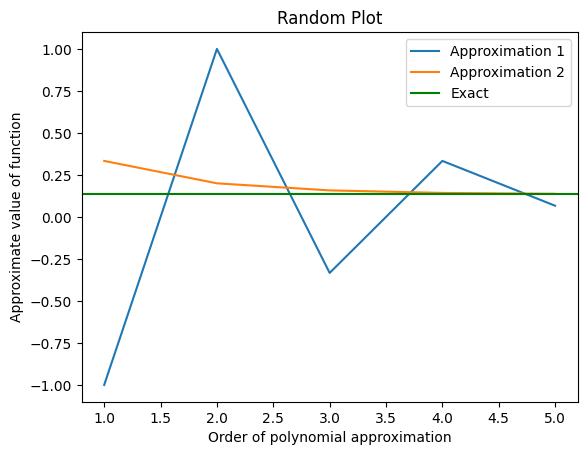

In [42]:
import matplotlib.pyplot as plt
orders = range(1, len(relative_error1)+1)
fig, ax = plt.subplots()
# your code goes here
plt.plot(orders,approximations1, label='Approximation 1')
plt.plot(orders,approximations2, label='Approximation 2')


plt.xlabel("Order of polynomial approximation")
plt.ylabel("Approximate value of function")
plt.axhline(y=exact, color='g', label='Exact')
# change title appropriately
plt.title("Random Plot")

plt.legend()
# save the plot to a file
plt.savefig("csc349a_asn1_q3.png", dpi=300, bbox_inches='tight')

# Display the plot
plt.show()


# set the best approximation to either "Approximation 1" or "Approximation 2"
# depending on which one you consider best
best_approximation = "Approximation 2"